<a href="https://colab.research.google.com/github/Shrutii-42/my-project/blob/main/Book__recomendation_system_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-surprise

In [ ]:
import pandas as pd
from surprise import Dataset, Reader, KNNBasic
from surprise.model_selection import train_test_split
from surprise import accuracy

In [ ]:
books = pd.read_csv("/content/books.csv")
ratings = pd.read_csv("/content/ratings.csv")

In [ ]:
ratings = ratings.sample(100000)
print("Reduced ratings size:", ratings.shape)

Reduced ratings size: (100000, 3)


In [ ]:
reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    ratings[['user_id','book_id','rating']],
    reader
)

In [ ]:
trainset, testset = train_test_split(data, test_size=0.2)

In [ ]:
model = KNNBasic()
model.fit(trainset)

Computing the msd similarity matrix...
Done computing similarity matrix.


In [ ]:
predictions = model.test(testset)
print("RMSE:", accuracy.rmse(predictions))

RMSE: 1.0250
RMSE: 1.0250231909769836


In [ ]:
user_id = 10
book_id = 50

pred = model.predict(user_id, book_id)
print("Predicted Rating:", pred.est)

Predicted Rating: 3.8537625


In [ ]:
book_dict = dict(zip(books.book_id, books.title))
print("Book Name:", book_dict.get(book_id))

Book Name: Hatchet (Brian's Saga, #1)


In [ ]:
user_id = 15

all_books = books['book_id'].unique()
rated_books = ratings[ratings['user_id'] == user_id]['book_id']

books_to_predict = [book for book in all_books if book not in rated_books]

predictions_list = []

for book in books_to_predict[:100]:
    pred = model.predict(user_id, book)
    predictions_list.append((book, pred.est))

predictions_list.sort(key=lambda x: x[1], reverse=True)

top_books = predictions_list[:5]

print("\nTop Recommended Books:\n")

for book_id, rating in top_books:
    print(book_dict.get(book_id), "-> Predicted Rating:", round(rating,2))


Top Recommended Books:

The Hunger Games (The Hunger Games, #1) -> Predicted Rating: 3.85
Harry Potter and the Sorcerer's Stone (Harry Potter, #1) -> Predicted Rating: 3.85
Twilight (Twilight, #1) -> Predicted Rating: 3.85
To Kill a Mockingbird -> Predicted Rating: 3.85
The Great Gatsby -> Predicted Rating: 3.85


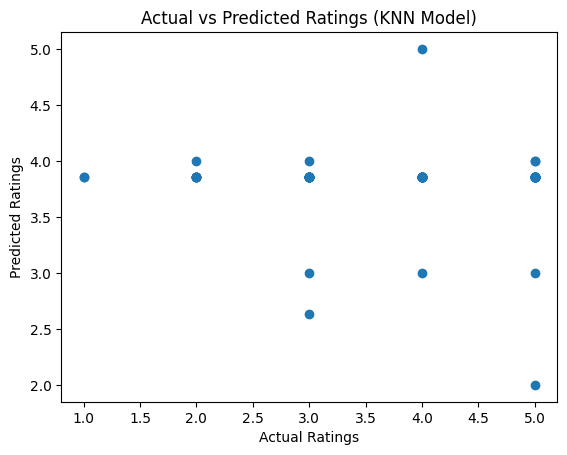

In [ ]:
import matplotlib.pyplot as plt


actual = [pred.r_ui for pred in predictions]
predicted = [pred.est for pred in predictions]


actual = actual[:100]
predicted = predicted[:100]

plt.scatter(actual, predicted)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (KNN Model)")
plt.show()